---
## This script will create Supplemental Fig's (10 - 11) drafts. I'm using 3˚ latitude bins.
### adding in CI's from the bootsrap-resampling robustness checks
##### 6/18/26
---

In [2]:
# kernel: pangeo23

In [3]:
# imports
import os
import xarray as xr
import numpy as np
import netCDF4 
import glob
import pandas as pd
import geopandas as gpd
from datetime import datetime
from scipy import stats
from scipy.spatial import cKDTree

from coastal_analysis_fns import *

In [4]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D 

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
script = 'FigS10S11_resubmissionJun26.ipynb'

In [7]:
# dataframe with the stations we are using
df = pd.read_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded.csv')
df = df.drop(['Unnamed: 0'], axis=1)

# convert df into geodataframe for ease of plotting
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(x=df.LON, y=df.LAT))

In [8]:
## load in bootstrapped data (all of them) into a nested dictionary
varnamelist = ['sst', 'tx', 'td', 'slp', 'windspeed', 'slhf', 'sshf', 'ssr', 'str', 'slhfSTA', 'sshfSTA', 'ssrSTA', 'strSTA', 'mld']

data_in_dict = {}

for szn in ['w', 'c']:    
    
    data_in_dict[szn] = {}
    
    for ev_type in ['MHW', 'THW', 'CON']:

        data_in_dict[szn][ev_type] = {}
        
        for varname in varnamelist:

            data_in_dict[szn][ev_type][varname] = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/{}_{}_{}_latbinned_bootmeans.nc'.format(varname, ev_type, szn))[varname]

## Plot

In [9]:
# generate list of letters to label each subplot
import string

ltrs = list(string.ascii_lowercase)

ltrs_plus_a = []
ltrs_plus_b = []

for ll in ltrs: 
    
    ltrs_plus_a.append('a'+ll)
    ltrs_plus_b.append('b'+ll)
    
letters_list = ltrs + ltrs_plus_a + ltrs_plus_b

In [10]:
# set cmap for tx
vmin = 0
vmax = 3
ncol_tx = 11
bounds_tx = np.linspace(vmin, vmax, ncol_tx)
cols = plt.get_cmap('Reds')(np.linspace(0,1,len(bounds_tx)+1))
cmap_tx = colors.ListedColormap(cols[1:-1])
cmap_tx.set_over(cols[-1])
cmap_tx.set_under('lightblue')
norm_tx = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# set cmap for sst
vmin = 0
vmax = 2
ncol_s = 11
bounds_s = np.linspace(vmin, vmax, ncol_s)
cols = plt.get_cmap('Reds')(np.linspace(0,1,len(bounds_s)+1))
cmap_s = colors.ListedColormap(cols[1:-1])
cmap_s.set_over(cols[-1])
cmap_s.set_under('lightblue')
norm_s = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# set cmap for slp
vmin = -4
vmax = 4
ncol_sl = 11
bounds_sl = np.linspace(vmin, vmax, ncol_sl)
cols = plt.get_cmap('RdBu_r')(np.linspace(0,1,len(bounds_sl)+1))
cmap_sl = colors.ListedColormap(cols[1:-1])
cmap_sl.set_over(cols[-1])
cmap_sl.set_under(cols[0])
norm_sl= mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# set cmap for wind
vmin = -1
vmax = 1
ncol_w = 11
bounds_w = np.linspace(vmin, vmax, ncol_w)
cols = plt.get_cmap('RdBu_r')(np.linspace(0,1,len(bounds_w)+1))
cmap_w = colors.ListedColormap(cols[1:-1])
cmap_w.set_over(cols[-1])
cmap_w.set_under(cols[0])
norm_w= mpl.colors.Normalize(vmin=vmin, vmax=vmax)

In [11]:
# heat flux cmap
vmin = -50
vmax = 50
ncol = 11
bounds = np.linspace(vmin, vmax, ncol)
cols = plt.get_cmap('RdBu_r')(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap_hf, norm_hf, bounds_hf = (cmap, norm, bounds)

In [12]:
# pctile (MLD) cmap
vmin = 25
vmax = 75
ncol = 11
bounds = np.linspace(vmin, vmax, ncol)
cols = plt.get_cmap('RdBu_r')(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap_mld, norm_mld, bounds_mld = (cmap, norm, bounds)

In [13]:
print('Done')

Done


NEW VERSION OF FIGURE S4 6/19/26


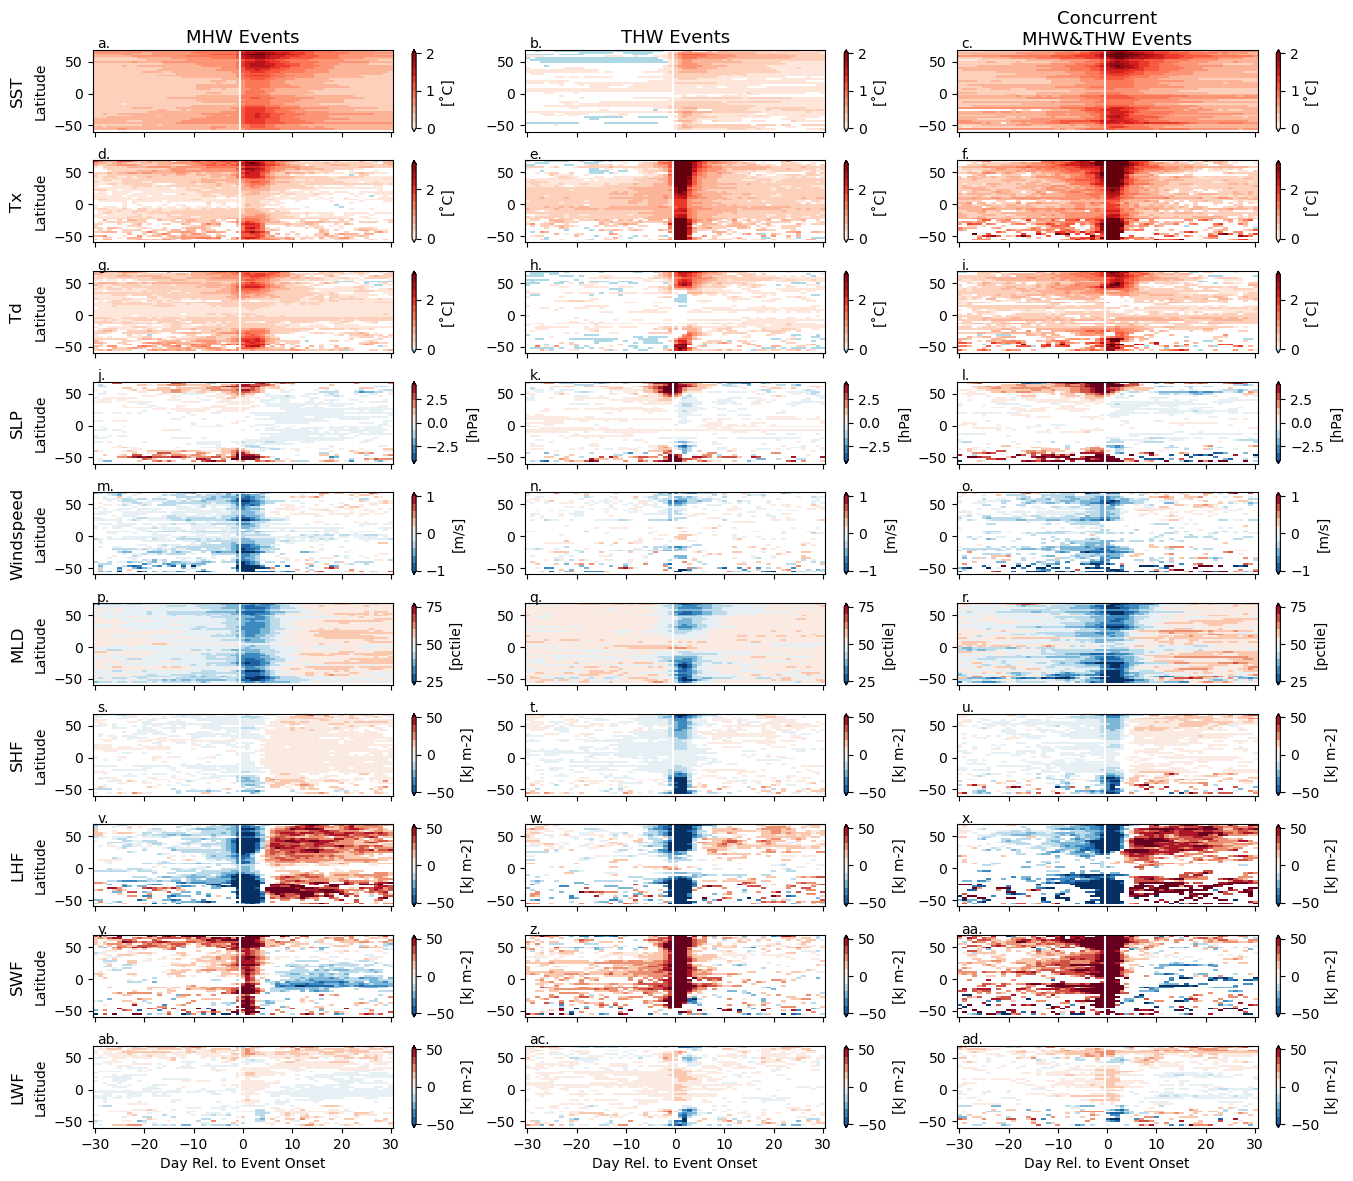

In [14]:
## WARM SEASON LEAD-LAGS (S4) -- Going to save this one
szn = 'w'

# set up figure
nrows = 10
ncols = 3
fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig) 
gs.update(wspace=0.15, hspace=0.35)


#to_plot_list = [[sst_binlag_MHW_w, sst_binlag_THW_w, sst_binlag_con_w],
#                [tx_binlag_MHW_w , tx_binlag_THW_w, tx_binlag_con_w],
#                [td_binlag_MHW_w, td_binlag_THW_w, td_binlag_con_w],
#                [slp_binlag_MHW_w, slp_binlag_THW_w, slp_binlag_con_w],
#                [windspeeds_binlag_MHW_w, windspeeds_binlag_THW_w, windspeeds_binlag_con_w], 
#                [MLDPctile_binlag_MHW_w, MLDPctile_binlag_THW_w, MLDPctile_binlag_con_w],
#                [sshf_binlag_MHW_w, sshf_binlag_THW_w, sshf_binlag_con_w], 
#                [slhf_binlag_MHW_w, slhf_binlag_THW_w, slhf_binlag_con_w],
#                [ssr_binlag_MHW_w, ssr_binlag_THW_w, ssr_binlag_con_w],
#                [str_binlag_MHW_w, str_binlag_THW_w, str_binlag_con_w]]

cmap_list = [cmap_s, cmap_tx, cmap_tx, cmap_sl, cmap_w, cmap_mld, cmap_hf, cmap_hf, cmap_hf, cmap_hf]
norm_list = [norm_s, norm_tx, norm_tx, norm_sl, norm_w, norm_mld, norm_hf, norm_hf, norm_hf, norm_hf]
bounds_list = [bounds_s, bounds_tx, bounds_tx, bounds_sl, bounds_w, bounds_mld, bounds_hf, bounds_hf, bounds_hf, bounds_hf]
cmap_label_list = ['[˚C]', '[˚C]', '[˚C]', '[hPa]', '[m/s]', '[pctile]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]']
row_label_list = ['SST', 'Tx', 'Td', 'SLP', 'Windspeed', 'MLD', 'SHF', 'LHF', 'SWF', 'LWF']

axes = []

pltctr = 0
for r, var in enumerate(['sst', 'tx', 'td', 'slp', 'windspeed', 'mld', 'sshf', 'slhf', 'ssr', 'str']): # not doing the over-station HF's here, specifying my own order also
    for c, ev_type in enumerate(['MHW', 'THW', 'CON']):
        
        ax = fig.add_subplot(gs[r, c])

        # select the appropriate data
        data2plot_boot_arr = data_in_dict[szn][ev_type][var]

        # create 50th percentile to plot
        data2plot_boot_meds = data2plot_boot_arr.quantile(0.5, dim='boot')
        
        # generate 95% CI and significance mask (insignificant if CI crosses 0)
        data2plot_boot_hici = data2plot_boot_arr.quantile(0.975, dim='boot')
        data2plot_boot_loci = data2plot_boot_arr.quantile(0.025, dim='boot')
        stat_sig_with_ci = np.logical_not((data2plot_boot_hici > 0) * (data2plot_boot_loci < 0)) # i guess i'm generating a mask of what IS significant,
            # and then stippling the spaces that aren't sig. 
        
        # plot the actual data (masked so "insignificant" areas aren't plotted
        data2plot_boot_meds.where(stat_sig_with_ci).plot(ax=ax, cmap=cmap_list[r], norm=norm_list[r], cbar_kwargs={'label':cmap_label_list[r], 'extend':'both'})

        # stipple out insignificant spots
        #stat_sig_with_ci.plot.contourf(ax=ax, hatches=['...', ''], levels=[-0.5, 0.5, 1.5], colors='none', add_colorbar=False)
        
        ax.axvline(-0.5, color='white')
        ax.set(title='', xlabel='', ylabel='')
        
        if not r==(nrows-1):
            ax.set_xticks([-30., -20., -10.,   0.,  10.,  20.,  30.], labels='')
        else:
            ax.set_xticks([-30., -20., -10.,   0.,  10.,  20.,  30.])
            ax.set(xlabel='Day Rel. to Event Onset')
            
        if c==0:
            ax.set(ylabel='Latitude')
            
        ax.text(s='{}.'.format(letters_list[pltctr]), x=0.015, y=1.02, transform=ax.transAxes, ha='left', fontsize=10)
            
        axes.append(ax)
        pltctr+=1 
            
# subplot labels
axes[0].text(x=0.5, y=1.15, s='MHW Events', va='center', ha='center', fontsize='13',
    transform=axes[0].transAxes)

axes[1].text(x=0.5, y=1.15, s='THW Events', va='center', ha='center', fontsize='13',
    transform=axes[1].transAxes)

axes[2].text(x=0.5, y=1.25, s='Concurrent\nMHW&THW Events', va='center', ha='center', fontsize='13',
    transform=axes[2].transAxes)

# y labels
for r in range(nrows):
    aa = axes[0+(r*3)]
    aa.text(x=-0.25, y=0.50, s=row_label_list[r], va='center', ha='center',
        rotation='vertical', rotation_mode='anchor', fontsize='12',
        transform=aa.transAxes)
    
    
# SAVE FIGURE
plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_resubmission_6.2026/FigS10_coastalsst_grl_7_26_latbin_fig3_w.png', format='png', bbox_inches='tight')
print('NEW VERSION OF FIGURE S4 6/19/26')

plt.show()

NEW VERSION OF FIGURE S5 6/19/26


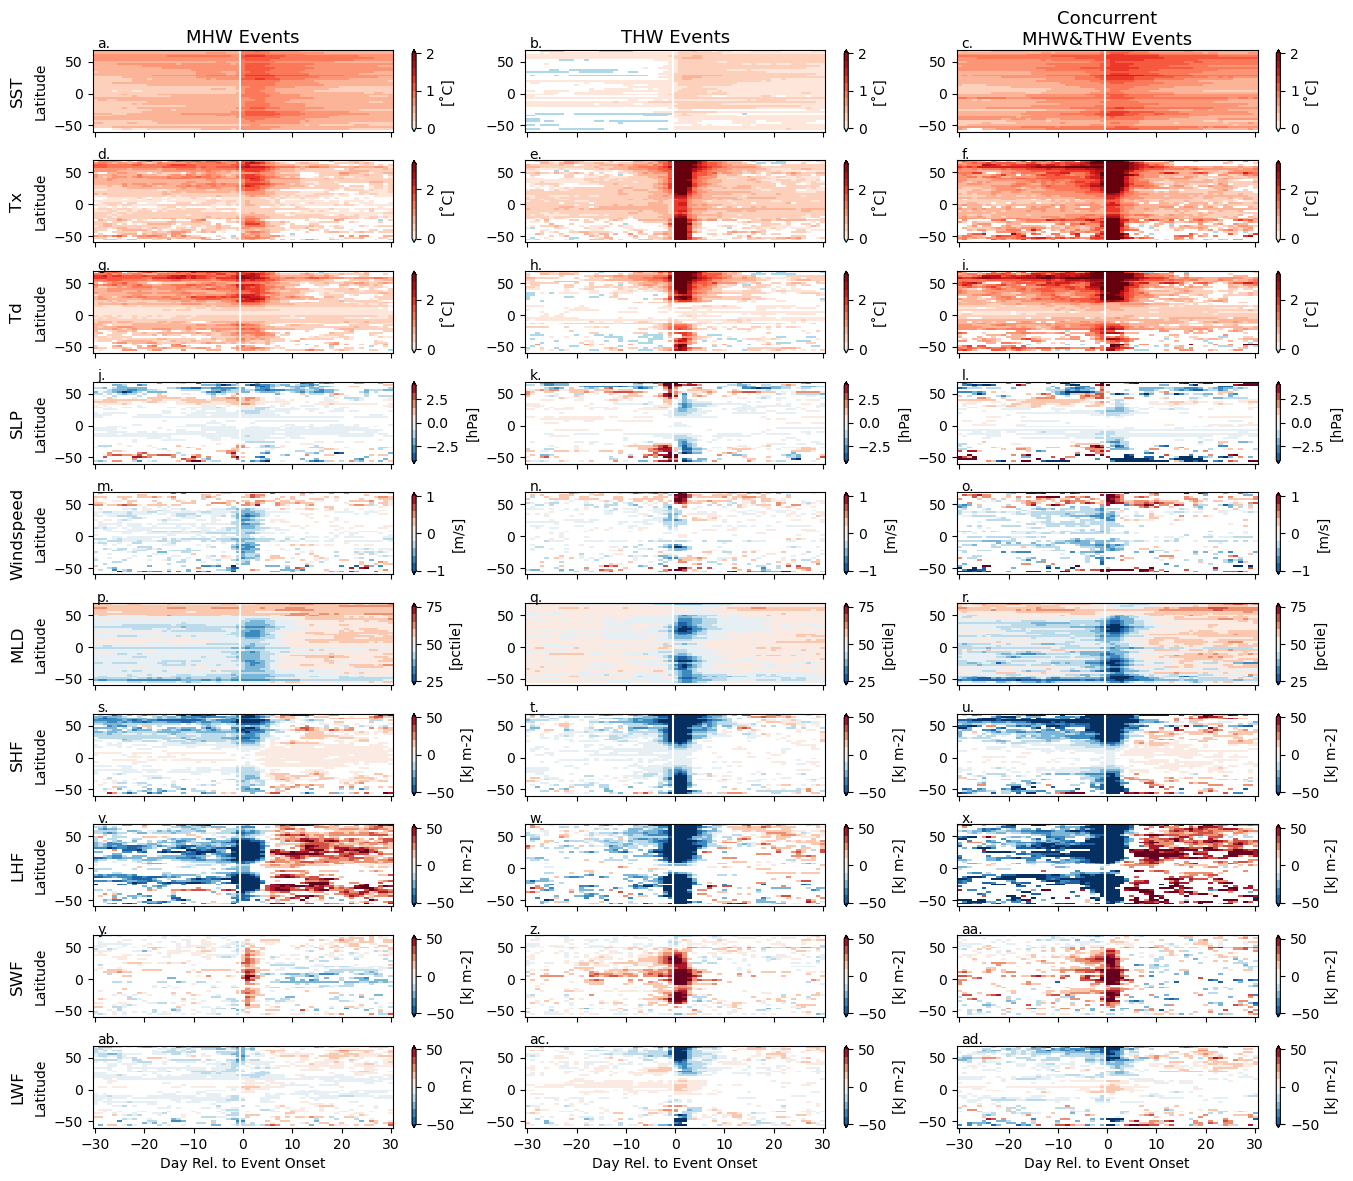

In [15]:
## COLD SEASON LEAD-LAGS (S5) -- Going to save this one
szn = 'c' # I think all I have to change is this. WHy didn't I use nested dicts before. Jeez. 

# set up figure
nrows = 10
ncols = 3
fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig) 
gs.update(wspace=0.15, hspace=0.35)

#cmap_list = [cmap_s, cmap_tx, cmap_tx, cmap_sl, cmap_w, cmap_mld, cmap_hf, cmap_hf, cmap_hf, cmap_hf]
#norm_list = [norm_s, norm_tx, norm_tx, norm_sl, norm_w, norm_mld, norm_hf, norm_hf, norm_hf, norm_hf]
#bounds_list = [bounds_s, bounds_tx, bounds_tx, bounds_sl, bounds_w, bounds_mld, bounds_hf, bounds_hf, bounds_hf, bounds_hf]
#cmap_label_list = ['[˚C]', '[˚C]', '[˚C]', '[hPa]', '[m/s]', '[pctile]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]']
#row_label_list = ['SST', 'Tx', 'Td', 'SLP', 'Windspeed', 'MLD', 'SHF', 'LHF', 'SWF', 'LWF']

axes = []

pltctr = 0
for r, var in enumerate(['sst', 'tx', 'td', 'slp', 'windspeed', 'mld', 'sshf', 'slhf', 'ssr', 'str']): # not doing the over-station HF's here, specifying my own order also
    for c, ev_type in enumerate(['MHW', 'THW', 'CON']):
        
        ax = fig.add_subplot(gs[r, c])

        # select the appropriate data
        data2plot_boot_arr = data_in_dict[szn][ev_type][var]

        # create 50th percentile to plot
        data2plot_boot_meds = data2plot_boot_arr.quantile(0.5, dim='boot')
        
        # generate 95% CI and significance mask (insignificant if CI crosses 0)
        data2plot_boot_hici = data2plot_boot_arr.quantile(0.975, dim='boot')
        data2plot_boot_loci = data2plot_boot_arr.quantile(0.025, dim='boot')
        stat_sig_with_ci = np.logical_not((data2plot_boot_hici > 0) * (data2plot_boot_loci < 0)) # i guess i'm generating a mask of what IS significant,
            # and then stippling the spaces that aren't sig. 
        
        # plot the actual data (masked so "insignificant" areas aren't plotted
        data2plot_boot_meds.where(stat_sig_with_ci).plot(ax=ax, cmap=cmap_list[r], norm=norm_list[r], cbar_kwargs={'label':cmap_label_list[r], 'extend':'both'})

        # stipple out insignificant spots
        #stat_sig_with_ci.plot.contourf(ax=ax, hatches=['...', ''], levels=[-0.5, 0.5, 1.5], colors='none', add_colorbar=False)
        
        ax.axvline(-0.5, color='white')
        ax.set(title='', xlabel='', ylabel='')
        
        if not r==(nrows-1):
            ax.set_xticks([-30., -20., -10.,   0.,  10.,  20.,  30.], labels='')
        else:
            ax.set_xticks([-30., -20., -10.,   0.,  10.,  20.,  30.])
            ax.set(xlabel='Day Rel. to Event Onset')
            
        if c==0:
            ax.set(ylabel='Latitude')
            
        ax.text(s='{}.'.format(letters_list[pltctr]), x=0.015, y=1.02, transform=ax.transAxes, ha='left', fontsize=10)
            
        axes.append(ax)
        pltctr+=1 
            
# subplot labels
axes[0].text(x=0.5, y=1.15, s='MHW Events', va='center', ha='center', fontsize='13',
    transform=axes[0].transAxes)

axes[1].text(x=0.5, y=1.15, s='THW Events', va='center', ha='center', fontsize='13',
    transform=axes[1].transAxes)

axes[2].text(x=0.5, y=1.25, s='Concurrent\nMHW&THW Events', va='center', ha='center', fontsize='13',
    transform=axes[2].transAxes)

# y labels
for r in range(nrows):
    aa = axes[0+(r*3)]
    aa.text(x=-0.25, y=0.50, s=row_label_list[r], va='center', ha='center',
        rotation='vertical', rotation_mode='anchor', fontsize='12',
        transform=aa.transAxes)
    
    
# SAVE FIGURE
plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_resubmission_6.2026/FigS11_coastalsst_grl_7_26_latbin_fig3_c.png', format='png', bbox_inches='tight')
print('NEW VERSION OF FIGURE S5 6/19/26')

plt.show()